In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_context("paper")

In [17]:
cities = {
    "1251066": "Sydney",
    "185567": "Belém",
    "1933745": "Cambridge USA",
    "2315704": "Boston",
    "2697338": "Rio de Janeiro",
    "271110": "Amsterdam",
    "347950": "Barcelona",
    "44915": "Milan",
    "536780": "Singapore",
    "79604": "Cape Town",
    "8896976": "Tunis",
    "913110": "Hong Kong"
}

overlap = 128
df = pd.read_csv(f'/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/all_masked/results/evaluation/metrics_stitch_{overlap}.csv')

def fix_legend(plot):
    plot._legend.set_title("City")
    for text in plot._legend.texts:
        city = cities[text.get_text()]
        text.set_text(city)

    sns.move_legend(plot, "upper right", bbox_to_anchor=(0.85, 0.95), frameon=True)

In [18]:
# df

In [19]:
RMSE = f"${df.loc[:, 'RMSE'].mean().round(3)} plus.minus {df.loc[:, 'RMSE'].std().round(3)}$"
SSIM = f"${df.loc[:, 'SSIM'].mean().round(3)} plus.minus {df.loc[:, 'SSIM'].std().round(3)}$"
MAE = f"${df.loc[:, 'MAE'].mean().round(3)} plus.minus {df.loc[:, 'MAE'].std().round(3)}$"
runtime = f"${df.loc[:, 'runtime'].mean().round(3)} plus.minus {df.loc[:, 'runtime'].std().round(3)}$"
# [0], [0.589], [0.207], [0.395], [1.432 Seconds],
print(f"[{overlap}], [{RMSE}], [{SSIM}], [{MAE}], [{runtime}s],")

[128], [$0.454 plus.minus 0.096$], [$0.41 plus.minus 0.131$], [$0.243 plus.minus 0.095$], [$6.081 plus.minus 0.157$s],


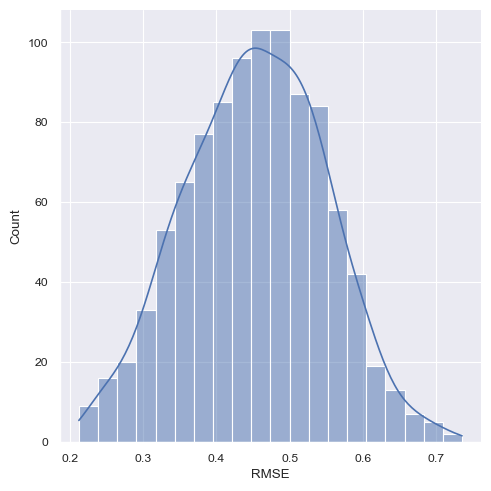

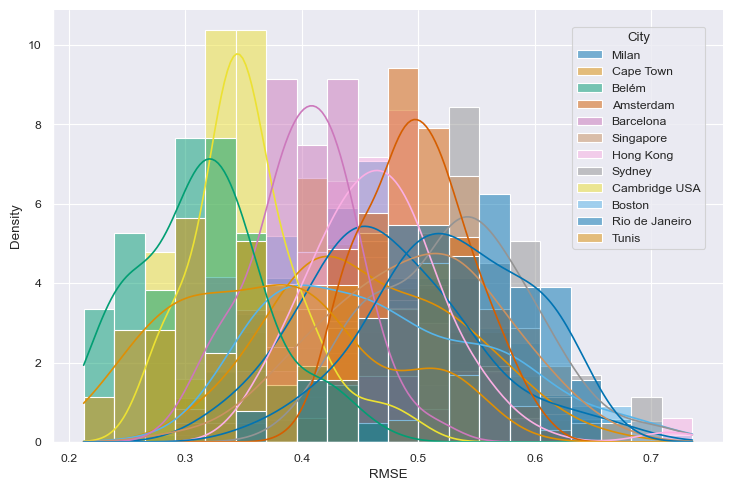

In [8]:
sns.displot(data=df, x="RMSE", kde=True, bins=20)

hist = sns.displot(data=df, x="RMSE", hue="osmid", kde=True, bins=20, palette="colorblind", stat="density", common_norm=False, aspect=1.5, facet_kws={'legend_out': True})

fix_legend(hist)

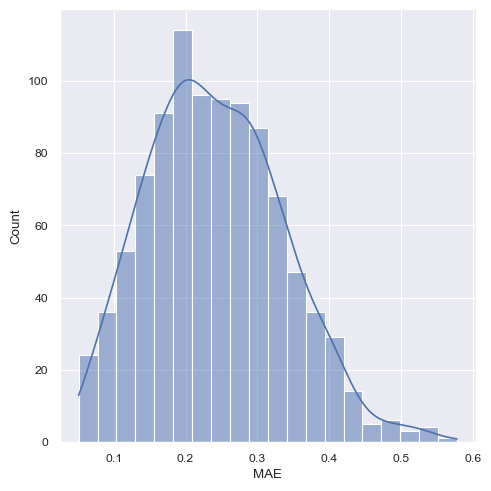

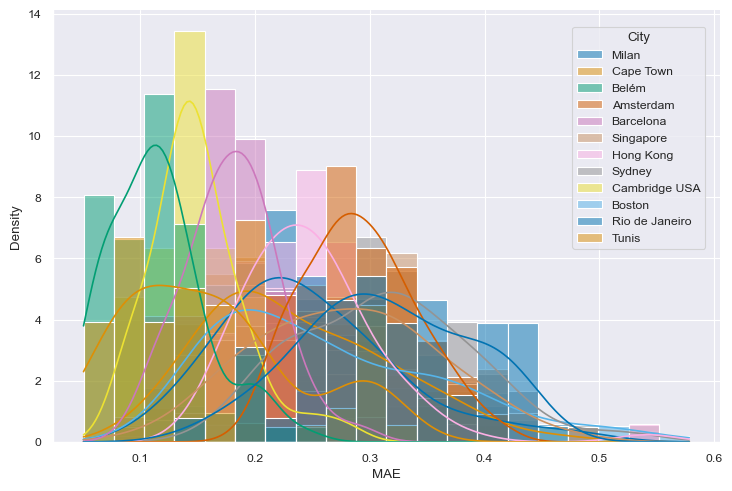

In [9]:
sns.displot(data=df, x="MAE", kde=True, bins=20)

hist = sns.displot(data=df, x="MAE", hue="osmid", kde=True, bins=20, palette="colorblind", stat="density", common_norm=False, aspect=1.5, facet_kws={'legend_out': True})

fix_legend(hist)

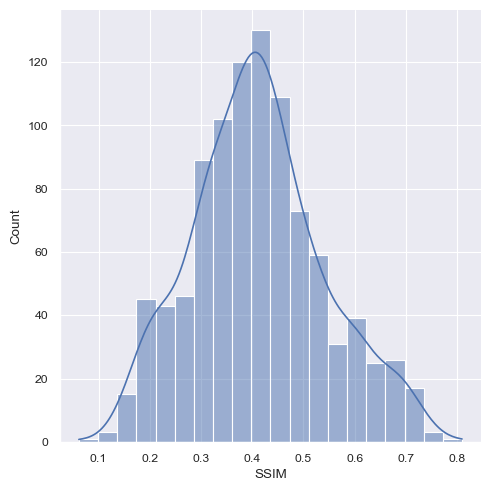

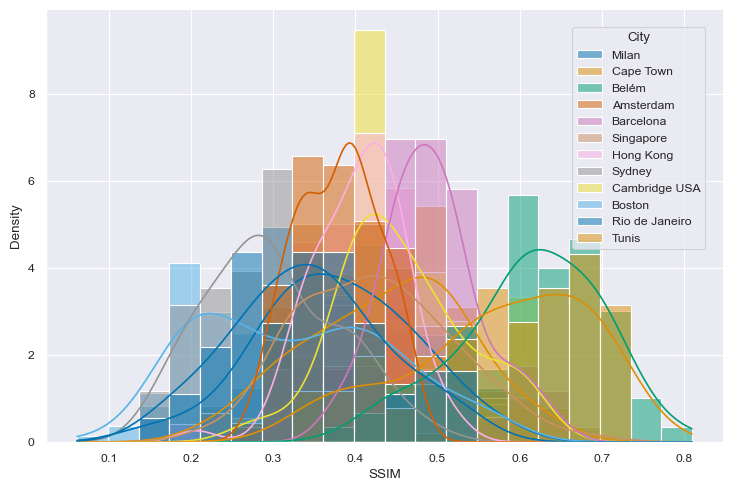

In [10]:
sns.displot(data=df, x="SSIM", kde=True, bins=20)

hist = sns.displot(data=df, x="SSIM", hue="osmid", kde=True, bins=20, palette="colorblind", stat="density", common_norm=False, aspect=1.5, facet_kws={'legend_out': True})

fix_legend(hist)

In [48]:
gb = df.groupby("osmid")

In [49]:
gb.describe()

tile                                                  RMSE  \
         count   mean  std    min    25%    50%    75%    max  count   
osmid                                                                  
44915     49.0  317.0  0.0  317.0  317.0  317.0  317.0  317.0   49.0   
79604     68.0  469.0  0.0  469.0  469.0  469.0  469.0  469.0   68.0   
185567    80.0   78.0  0.0   78.0   78.0   78.0   78.0   78.0   80.0   
271110   126.0  403.0  0.0  403.0  403.0  403.0  403.0  403.0  126.0   
347950    46.0  231.0  0.0  231.0  231.0  231.0  231.0  231.0   46.0   
536780    80.0  818.0  0.0  818.0  818.0  818.0  818.0  818.0   80.0   
913110    64.0  115.0  0.0  115.0  115.0  115.0  115.0  115.0   64.0   
1251066   68.0    5.0  0.0    5.0    5.0    5.0    5.0    5.0   68.0   
1933745   48.0   39.0  0.0   39.0   39.0   39.0   39.0   39.0   48.0   
2315704  214.0  218.0  0.0  218.0  218.0  218.0  218.0  218.0  214.0   
2697338   65.0  247.0  0.0  247.0  247.0  247.0  247.0  247.0   65.0   
8896976   69.0   87.0  0.0   87.0   87.0   87.0   87.0   87.0   69.0   

                   ...       MAE           runtime                      \
             mean  ...       75%       max   count      mean       std   
osmid              ...                                                   
44915    0.582627  ...  0.426252  0.514685    49.0  1.327724  0.040020   
79604    0.490679  ...  0.337876  0.577327    68.0  1.484967  0.023483   
185567   0.522647  ...  0.347140  0.519732    80.0  1.314370  0.021804   
271110   0.511756  ...  0.342032  0.466409   126.0  1.444543  0.032949   
347950   0.510465  ...  0.316855  0.385655    46.0  1.404294  0.024467   
536780   0.509602  ...  0.330744  0.564642    80.0  1.463760  0.024621   
913110   0.557429  ...  0.374312  0.457953    64.0  1.484089  0.027343   
1251066  0.563406  ...  0.388514  0.560617    68.0  1.490613  0.018500   
1933745  0.449239  ...  0.247358  0.400599    48.0  1.333613  0.026776   
2315704  0.522245  ...  0.362140  0.630547   214.0  1.488213  0.021369   
2697338  0.557472  ...  0.380174  0.637696    65.0  1.484403  0.015068   
8896976  0.518965  ...  0.334990  0.515170    69.0  1.478781  0.014823   

                                                           
              min       25%       50%       75%       max  
osmid                                                      
44915    1.274874  1.302575  1.310862  1.331213  1.450517  
79604    1.410577  1.473429  1.482825  1.493474  1.561107  
185567   1.276088  1.299683  1.311046  1.323920  1.398185  
271110   1.355562  1.431574  1.445599  1.457708  1.543599  
347950   1.359385  1.394595  1.403511  1.413027  1.477179  
536780   1.392712  1.452879  1.460606  1.468880  1.552585  
913110   1.396039  1.471981  1.482683  1.495793  1.619088  
1251066  1.462761  1.479030  1.488726  1.496592  1.582698  
1933745  1.294257  1.315187  1.327673  1.347847  1.431084  
2315704  1.420782  1.476886  1.486540  1.499000  1.584973  
2697338  1.455203  1.474663  1.482695  1.490691  1.545041  
8896976  1.446849  1.469871  1.477402  1.488227  1.522354  

[12 rows x 40 columns]